# **PROYECTO: ANÁLISIS DE EXPLORATORIO DE DATOS**

Una vez visto el ***Módulo 3: Introducción al Análisis de Datos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar todo el proceso que involucra el **análisis de datos** donde el tema a emplear es libre ya que dependerá del **dataset a escoger**. Cada **proceso del análisis** deberá ser mostrado en este notebook:

*   **Recopilación de datos.**
*   **Limpieza de datos.**
*   **Exploración de datos.**
*   **Visualización de datos.**

# **MALTRATO ANIMAL**


## **¿Es el maltrato animal un problema real en México?** 🙁🐕🐈🇲🇽


Actualmente, no se encuentran registros útiles y completos sobre maltrato animal. Aunque instituciones como el INEGI y gobiernos estatales promueven la transparencia de la información, adquirir información real y concisa sobre los reportes que se reciben de maltrato animal a nivel estatal (ya no se diga a nivel federal) es un verdadero reto.

Acudimos directa y virtualmente a instancias como:
* Secretaría de Infraestructura de Tizayuca
  * CECOBAM
* Procuratel
* Secretaria de Seguridad Ciudadana (089)
* Refugios locales
  * ARCY adopciones y rescates
  * Proeza por el Respeto Animal en Tizayuca (PRAT)
  * La madriguera del michi
  * Humane World for Animals
  * Libertad Apasdem

Y nadie, ninguna instancia, tiene o sabe dónde conseguir dicha información. Lo que genera una preocupante incognita, ¿por qué una instancia como procuratel o el 089 no saben ni tienen registros a la mano si son ellos el primer contacto de atención ciudadana?.


¿Realmente no los tienen o los tienen y los administrativos desconocen del tema?, ¿quién contesta las llamadas y registra el incidente, y qué hace con tales registros?
Es una situación alarmante, sin embargo, no es la rama principal de este análisis.

Derivado de esta dificultad, nos apoyamos de META AI para obtener un data set con ifnormación de resgistros de maltrato animal a nivel federal.

Se adjunta prompt utilizado.

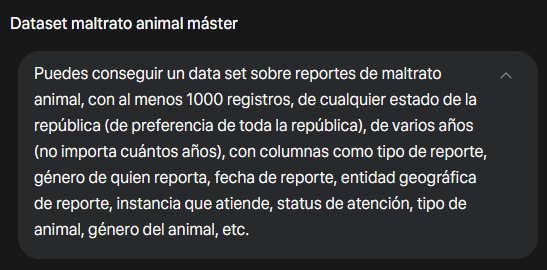

Meta entregó un concentrado de varias fuentes:

1. Consejo Ciudadano CDMX (nacional)

    Quien atendió 17,600 reportes entre 2020 y julio 2022 y 27,892 entre 2019 y mayo 2023, según comunicados oficiales.

2. PAOT CDMX

    Con 23,601 denuncias por maltrato animal de 2019 a 2025.

3. PROFEPA (federal)

Concentrado que contiene 1,500 registros de maltrato animal, de 2019 a 2025 y, de toda la República Mexicana, con las siguientes columnas:

`id_reporte`,

`fecha_reporte`,

`año`,

`entidad_federativa`,

`alcaldia_municipio`,

`tipo_reporte`,

`tipo_animal`,

`genero_animal`,

`genero_reportante`,

`edad_reportante_rango`,

`instancia_atiende`,

`estatus_atencion`,

`medio_denuncia`.

DataSet: `Reportes-maltrato-animal 19-25.cvs`

### **Nuestras preguntas de investigación**

1. **¿Existe el maltrato animal?**

De primera mano sabemos que sí! Indagaremos más al respecto.

2. **¿Existe la cultura de denunciar el maltrato animal?**

Sabemos que se puede y que sí existen reportes pero no sabemos si responden realmente a un tema de cultura o de "suerte".

3. **¿Las instancias correspondientes de recibir las denunciar registran y dan seguimiento adecuado a los reportes?**

4. **¿Por qué se minimiza el maltrato animal y que podemos aportar como individuos y sociedad para disminuir el mlatrato?**

## **Carga y reconocimiento**

In [160]:
# 1. Carga de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Carga de dataset
df_original = pd.read_csv("Reportes-maltrato-animal 19-25.csv")
df_copy = df_original.copy()
df_copy.head()


,id_reporte,fecha_reporte,año,entidad_federativa,alcaldia_municipio,tipo_reporte,tipo_animal,genero_animal,genero_reportante,edad_reportante_rango,instancia_atiende,estatus_atencion,medio_denuncia
0,MX-MA-00001,24/11/2022,2022,Ciudad de México,Venustiano Carranza,Hacinamiento,Perro,Hembra,Mujer,41-50,Fiscalía General de Justicia,Recibido,Redes sociales
1,MX-MA-00002,27/02/2025,2025,Ciudad de México,Iztapalapa,Criadero clandestino,Perro,Hembra,Mujer,21-30,Brigada de Vigilancia Animal,Recibido,Teléfono
2,MX-MA-00003,13/01/2024,2024,Hidalgo,Municipio 13,Falta de alimento,Perro,Macho,Mujer,51-60,Consejo Ciudadano,Concluido sin infracción,Teléfono
3,MX-MA-00004,21/05/2023,2023,Ciudad de México,Coyoacán,Falta de alimento,Perro,Hembra,Mujer,41-50,Brigada de Vigilancia Animal,En investigación,Redes sociales
4,MX-MA-00005,06/05/2021,2021,Ciudad de México,Tlalpan,Hacinamiento,Perro,Hembra,Mujer,21-30,PROFEPA,Con sanción,Chat


In [161]:
# 2. diagnóstico

# reconocimiento
df_copy.info()

# validación de nulos
print("\nValores nulos:\n", df_copy.isnull().sum())

# validación de duplicados
print("\nDuplicados:", df_copy.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id_reporte             1500 non-null   object
 1   fecha_reporte          1500 non-null   object
 2   año                    1500 non-null   int64 
 3   entidad_federativa     1500 non-null   object
 4   alcaldia_municipio     1500 non-null   object
 5   tipo_reporte           1500 non-null   object
 6   tipo_animal            1500 non-null   object
 7   genero_animal          1500 non-null   object
 8   genero_reportante      1500 non-null   object
 9   edad_reportante_rango  1500 non-null   object
 10  instancia_atiende      1500 non-null   object
 11  estatus_atencion       1500 non-null   object
 12  medio_denuncia         1500 non-null   object
dtypes: int64(1), object(12)
memory usage: 152.5+ KB

Valores nulos:
 id_reporte               0
fecha_reporte            0
año 

In [162]:
# Copiamos para retomar en caso de errores posteriores

df_diag = df_copy.copy()
df_diag.head()

,id_reporte,fecha_reporte,año,entidad_federativa,alcaldia_municipio,tipo_reporte,tipo_animal,genero_animal,genero_reportante,edad_reportante_rango,instancia_atiende,estatus_atencion,medio_denuncia
0,MX-MA-00001,24/11/2022,2022,Ciudad de México,Venustiano Carranza,Hacinamiento,Perro,Hembra,Mujer,41-50,Fiscalía General de Justicia,Recibido,Redes sociales
1,MX-MA-00002,27/02/2025,2025,Ciudad de México,Iztapalapa,Criadero clandestino,Perro,Hembra,Mujer,21-30,Brigada de Vigilancia Animal,Recibido,Teléfono
2,MX-MA-00003,13/01/2024,2024,Hidalgo,Municipio 13,Falta de alimento,Perro,Macho,Mujer,51-60,Consejo Ciudadano,Concluido sin infracción,Teléfono
3,MX-MA-00004,21/05/2023,2023,Ciudad de México,Coyoacán,Falta de alimento,Perro,Hembra,Mujer,41-50,Brigada de Vigilancia Animal,En investigación,Redes sociales
4,MX-MA-00005,06/05/2021,2021,Ciudad de México,Tlalpan,Hacinamiento,Perro,Hembra,Mujer,21-30,PROFEPA,Con sanción,Chat


## **Limpieza da datos**

In [163]:
# 1. Borrar columnas y crear nuevas para análisis

# borrar columna id_reporte
df_diag.drop('id_reporte', axis=1, inplace=True)

# Crear nueva columna para mes
# Convertir 'fecha_reporte' a datetime antes de extraer el mes
df_diag['fecha_reporte'] = pd.to_datetime(df_diag['fecha_reporte'], format='%d/%m/%Y', errors='coerce')
df_diag['mes'] = df_diag['fecha_reporte'].dt.month

df_diag['mes'].unique()

array([11,  2,  1,  5,  4,  3, 12, 10,  8,  9,  6,  7], dtype=int32)

In [164]:
# 2. Parsear la columna mes

reemplazos_mes = {
    1: 'ene',
    2: 'feb',
    3: 'mar',
    4: 'abr',
    5: 'may',
    6: 'jun',
    7: 'jul',
    8: 'ago',
    9: 'sep',
    10: 'oct',
    11: 'nov',
    12: 'dic'}
df_diag['mes'] = df_diag['mes'].replace(reemplazos_mes)

df_diag['mes'].value_counts()

,count
mes,
may,151
ago,144
oct,141
dic,138
feb,125
nov,121
jul,118
mar,118
ene,115


In [165]:
# 3. Limpiar y cambiar tipos de datos

# Dado que los datos vienen limpios no se aplicará limpieza (espacios, mayúsculas o regex)
# y como no hay nulos, ni duplicados, procederemos a modificar tipos de datos

cat_cols = df_diag.select_dtypes(include='object').columns

# Convertimos columnas a tipo de dato category
df_diag[cat_cols] = df_diag[cat_cols].astype('category')

df_diag.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   fecha_reporte          1500 non-null   datetime64[ns]
 1   año                    1500 non-null   int64         
 2   entidad_federativa     1500 non-null   category      
 3   alcaldia_municipio     1500 non-null   category      
 4   tipo_reporte           1500 non-null   category      
 5   tipo_animal            1500 non-null   category      
 6   genero_animal          1500 non-null   category      
 7   genero_reportante      1500 non-null   category      
 8   edad_reportante_rango  1500 non-null   category      
 9   instancia_atiende      1500 non-null   category      
 10  estatus_atencion       1500 non-null   category      
 11  medio_denuncia         1500 non-null   category      
 12  mes                    1500 non-null   category      
dtypes: 

In [166]:
df_diag.head()

,fecha_reporte,año,entidad_federativa,alcaldia_municipio,tipo_reporte,tipo_animal,genero_animal,genero_reportante,edad_reportante_rango,instancia_atiende,estatus_atencion,medio_denuncia,mes
0,2022-11-24,2022,Ciudad de México,Venustiano Carranza,Hacinamiento,Perro,Hembra,Mujer,41-50,Fiscalía General de Justicia,Recibido,Redes sociales,nov
1,2025-02-27,2025,Ciudad de México,Iztapalapa,Criadero clandestino,Perro,Hembra,Mujer,21-30,Brigada de Vigilancia Animal,Recibido,Teléfono,feb
2,2024-01-13,2024,Hidalgo,Municipio 13,Falta de alimento,Perro,Macho,Mujer,51-60,Consejo Ciudadano,Concluido sin infracción,Teléfono,ene
3,2023-05-21,2023,Ciudad de México,Coyoacán,Falta de alimento,Perro,Hembra,Mujer,41-50,Brigada de Vigilancia Animal,En investigación,Redes sociales,may
4,2021-05-06,2021,Ciudad de México,Tlalpan,Hacinamiento,Perro,Hembra,Mujer,21-30,PROFEPA,Con sanción,Chat,may


In [167]:
# 4. unique para cada columna

# validamos valores únicos
for col in df_diag.columns:
  print(f"{col}: {df_diag[col].unique()}")
  print("-"*200)
  print()


fecha_reporte: <DatetimeArray>
['2022-11-24 00:00:00', '2025-02-27 00:00:00', '2024-01-13 00:00:00',
 '2023-05-21 00:00:00', '2021-05-06 00:00:00', '2021-04-25 00:00:00',
 '2019-03-13 00:00:00', '2025-02-22 00:00:00', '2023-12-13 00:00:00',
 '2024-10-06 00:00:00',
 ...
 '2024-09-14 00:00:00', '2022-11-11 00:00:00', '2021-01-23 00:00:00',
 '2022-12-04 00:00:00', '2019-06-04 00:00:00', '2023-08-23 00:00:00',
 '2024-11-25 00:00:00', '2023-01-16 00:00:00', '2022-02-01 00:00:00',
 '2022-09-03 00:00:00']
Length: 1094, dtype: datetime64[ns]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

año: [2022 2025 2024 2023 2021 2019 2020]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

entidad_federa

In [168]:
# unique alcaldía_municipio

df_diag['alcaldia_municipio'].value_counts()

,count
alcaldia_municipio,
Cuauhtémoc,118
Álvaro Obregón,115
Gustavo A. Madero,111
Iztacalco,109
Azcapotzalco,108
Tlalpan,108
Benito Juárez,108
Venustiano Carranza,103
Iztapalapa,102


Dado que no contamos con los datos de los municipios de la República mexicana, y para efectos de esta investigación que se centra más en la CMDX, colocaremos una sóla categoría para todos los municipios.

In [169]:
# Parseo municipios
reemplazos_municipio = {
    'Municipio 1': 'Municipio',
    'Municipio 2': 'Municipio',
    'Municipio 3': 'Municipio',
    'Municipio 4': 'Municipio',
    'Municipio 5': 'Municipio',
    'Municipio 6': 'Municipio',
    'Municipio 7': 'Municipio',
    'Municipio 8': 'Municipio',
    'Municipio 9': 'Municipio',
    'Municipio 10': 'Municipio',
    'Municipio 11': 'Municipio',
    'Municipio 12': 'Municipio',
    'Municipio 13': 'Municipio',
    'Municipio 14': 'Municipio',
    'Municipio 15': 'Municipio'}
df_diag['alcaldia_municipio'] = df_diag['alcaldia_municipio'].replace(reemplazos_municipio)
df_diag['alcaldia_municipio'].value_counts()

/tmp/ipykernel_902/25889589.py:18: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



,count
alcaldia_municipio,
Municipio,418
Cuauhtémoc,118
Álvaro Obregón,115
Gustavo A. Madero,111
Iztacalco,109
Azcapotzalco,108
Benito Juárez,108
Tlalpan,108
Venustiano Carranza,103


Para género reportante = No especificado, se buscará la media para que sólo sean 2 generos. Considerando que representan tan sólo el 2% de la población aproximadamente y que sí existe un género contundentemente dominante.

In [170]:
df_diag['genero_reportante'].value_counts()


,count
genero_reportante,
Mujer,1081
Hombre,390
No especificado,29


In [171]:
# Parseo genero reportante
reemplazos_gen_rep = {
    'No especificado': 'Mujer'}
df_diag['genero_reportante'] = df_diag['genero_reportante'].replace(reemplazos_gen_rep)
df_diag['genero_reportante'].value_counts()

/tmp/ipykernel_902/352660396.py:4: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



,count
genero_reportante,
Mujer,1110
Hombre,390


A diferencia del género del animal, donde la categoría No específicado sí representa un porcentaje mayor, aproximadamente el 9%; y si bien, está dentro de los márgenes aceptables para modificar, la diferencia entre las otras 2 categorías es tan pequeña que asignar este 9% a un grupo sí puede cambiar el resultado del análisis. Por lo que dicha columna permanecerá con los mismos 3 grupos.

In [172]:
df_diag['genero_animal'].value_counts()


,count
genero_animal,
Macho,701
Hembra,668
No especificado,131


In [173]:
# hacemos copia del dataset limpio

df_clean = df_diag.copy()

# guardamos archivo
df_clean.to_csv('df_clean.csv', index=False)

df_clean.head()

,fecha_reporte,año,entidad_federativa,alcaldia_municipio,tipo_reporte,tipo_animal,genero_animal,genero_reportante,edad_reportante_rango,instancia_atiende,estatus_atencion,medio_denuncia,mes
0,2022-11-24,2022,Ciudad de México,Venustiano Carranza,Hacinamiento,Perro,Hembra,Mujer,41-50,Fiscalía General de Justicia,Recibido,Redes sociales,nov
1,2025-02-27,2025,Ciudad de México,Iztapalapa,Criadero clandestino,Perro,Hembra,Mujer,21-30,Brigada de Vigilancia Animal,Recibido,Teléfono,feb
2,2024-01-13,2024,Hidalgo,Municipio,Falta de alimento,Perro,Macho,Mujer,51-60,Consejo Ciudadano,Concluido sin infracción,Teléfono,ene
3,2023-05-21,2023,Ciudad de México,Coyoacán,Falta de alimento,Perro,Hembra,Mujer,41-50,Brigada de Vigilancia Animal,En investigación,Redes sociales,may
4,2021-05-06,2021,Ciudad de México,Tlalpan,Hacinamiento,Perro,Hembra,Mujer,21-30,PROFEPA,Con sanción,Chat,may


## **Análisis Exploratorio de Datos (EDA)**

In [174]:
# 1. Resumen estadístico

display(df_clean.describe(include='all').T)

# si bien la mayoría de las columnas son categóricas,
# la columna top del resumen nos proporciona información valiosa.

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
fecha_reporte,1500,NaN,NaN,NaN,2023-01-04 12:44:09.600000,2019-01-01 00:00:00,2021-08-24 18:00:00,2023-02-17 00:00:00,2024-07-05 18:00:00,2025-12-29 00:00:00,NaN
año,1500.0,NaN,NaN,NaN,2022.505333,2019.0,2021.0,2023.0,2024.0,2025.0,1.795584
entidad_federativa,1500,11,Ciudad de México,1082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcaldia_municipio,1500,11,Municipio,418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_reporte,1500,10,Falta de alimento,232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_animal,1500,6,Perro,1311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genero_animal,1500,3,Macho,701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genero_reportante,1500,2,Mujer,1110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad_reportante_rango,1500,6,31-40,342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instancia_atiende,1500,6,PAOT,522,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
# valores relevantes de la columna top

resumen_estadistico = df_clean.describe(include='category').T
display(resumen_estadistico['top'])

# --------------------------------------------

# guardar tabla como imagen
res_est = resumen_estadistico['top'].to_frame()

fig, ax = plt.subplots(figsize=(4, 3))
ax.axis('off')
ax.table(cellText=res_est.values, colLabels=res_est.columns,
         rowLabels=res_est.index, loc='center')
plt.title('Resumen estadístico')
plt.savefig('Resumen_Estadístico.jpg', bbox_inches='tight', dpi=300)
plt.close(fig)

# --------------------------------------------

,top
entidad_federativa,Ciudad de México
alcaldia_municipio,Municipio
tipo_reporte,Falta de alimento
tipo_animal,Perro
genero_animal,Macho
genero_reportante,Mujer
edad_reportante_rango,31-40
instancia_atiende,PAOT
estatus_atencion,En investigación
medio_denuncia,Teléfono


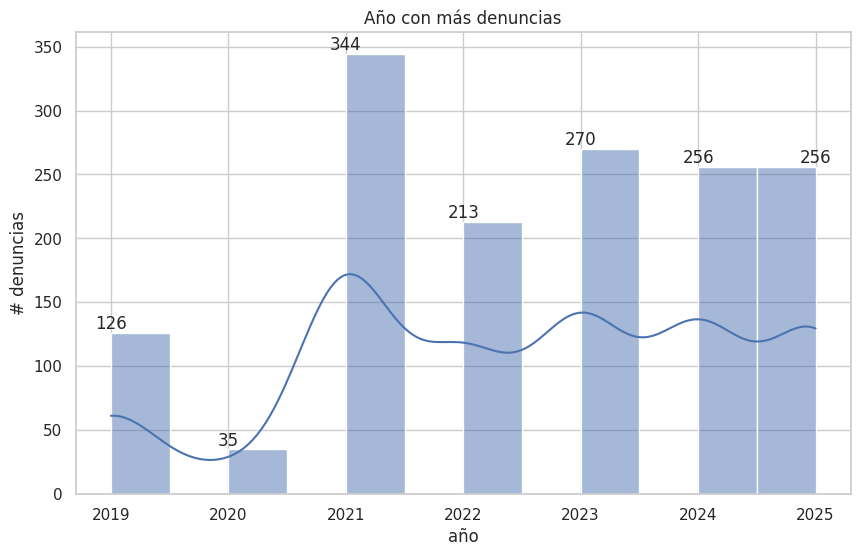

----------------------------------------------------------------------------------------------------
Año con más denuncias: 2021 con 344 denuncias
----------------------------------------------------------------------------------------------------


In [176]:
# 2. Análisis univariable

# Numéricas
plt.figure()
sns.histplot(df_clean['año'], kde=True)
plt.title('Año con más denuncias')
plt.ylabel('# denuncias')

# etiquetas para las barras
counts = df_clean['año'].value_counts().sort_index()
for year, count in counts.items():
    plt.text(year, count, str(int(count)), ha='center', va='bottom')

plt.show()

# resumen estadístico
print("-"*100)
print(f"Año con más denuncias: {df_clean['año'].mode()[0]} con {df_clean['año'].value_counts().max()} denuncias")
print("-"*100)


El año 2021 presenta una cantidad de denuncias bastante considerable y preocupante. La pregunta es, ¿qué tipo de maltrato se reporta o a qué tipo de falla cívica corresponde?.

Actualmente, el INEGI contempla las siguientes faltas cívicas respecto a los animales:

* Abstenerse de recoger las heces fecales de las mascotas en lugares públicos.

* Abandonar animales en lugares públicos

* Poseer animales sin adoptar medidas de seguridad para prevenir agresiones.

* Maltratar, golpear o mutilar a cualquier animal

* Participar u organizar peleas de animales

* Poseer animales sin adoptar medidas de higiene adecuadas

* Otras faltas cívicas relacionadas con la afectación a la seguridad y trato digno de los animales.  


Así mismo, la Dirección de K9 de la Secretaría de Seguridad Ciudadana, presenta un "violenciometro" que mide la violencia animal en 3 etapas:
* **Negligencia**
  * Falta de higiene al animalo
  * Dejarlos vagar en la calle
* **Maltrato**
  * Mantenerlos en un lugar no seguro (azotea o balcón)
  * Falta de asistencia veterinaria
* **Crueldad**
  * Envenenamiento
  * Peleas callejeras

Cómo podemos ver, los tipos de maltrato reportados corresponden con las faltas cívicas y el violenciómetro mencioando.

In [177]:
# tipos de maltrato reportados

unique_tipos_reporte = pd.Series(df_clean['tipo_reporte'].unique())
unique_tipos_reporte.rename('Tipos de reporte')

,Tipos de reporte
0,Hacinamiento
1,Criadero clandestino
2,Falta de alimento
3,Otro
4,Abandono
5,Animal amarrado
6,Falta de atención veterinaria
7,Agresión física
8,Peleas clandestinas
9,Maltrato en azotea


¿Cuál es la falta cívica más reportada?,  
¿corresponde al mismo año con más reportes?,  
¿cuál es el mes con mayor incidencias?,  
¿cuál es la ciudad con más reportes?,  
son algunas preguntas que nos surgen en este análisis.

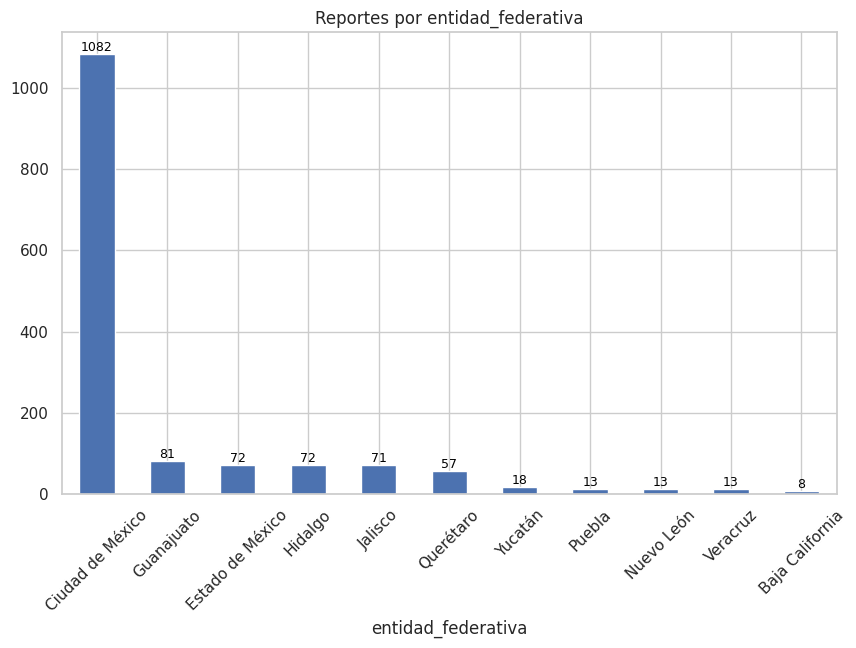

----------------------------------------------------------------------------------------------------
entidad_federativa con más reportes:
Ciudad de México con 1082 reportes
----------------------------------------------------------------------------------------------------



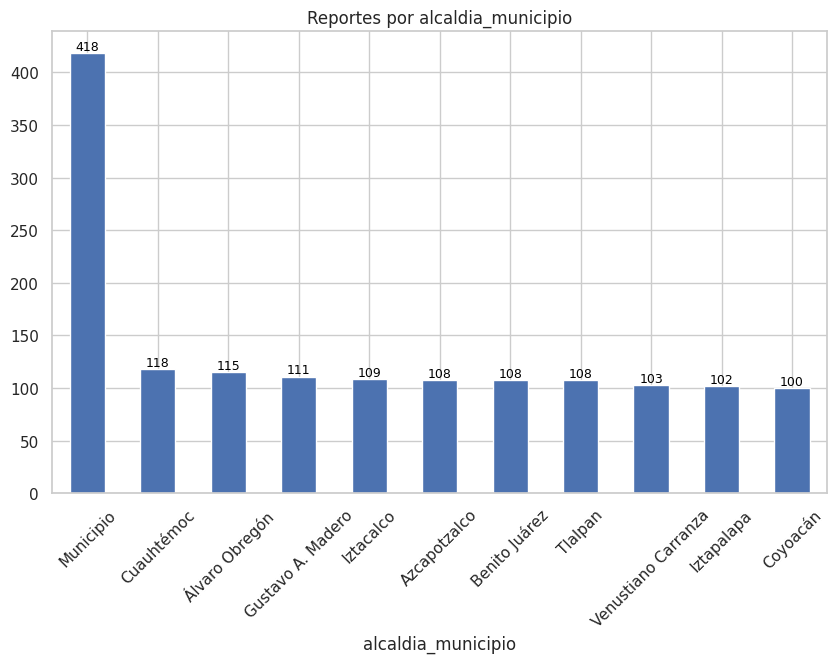

----------------------------------------------------------------------------------------------------
alcaldia_municipio con más reportes:
Municipio con 418 reportes
----------------------------------------------------------------------------------------------------



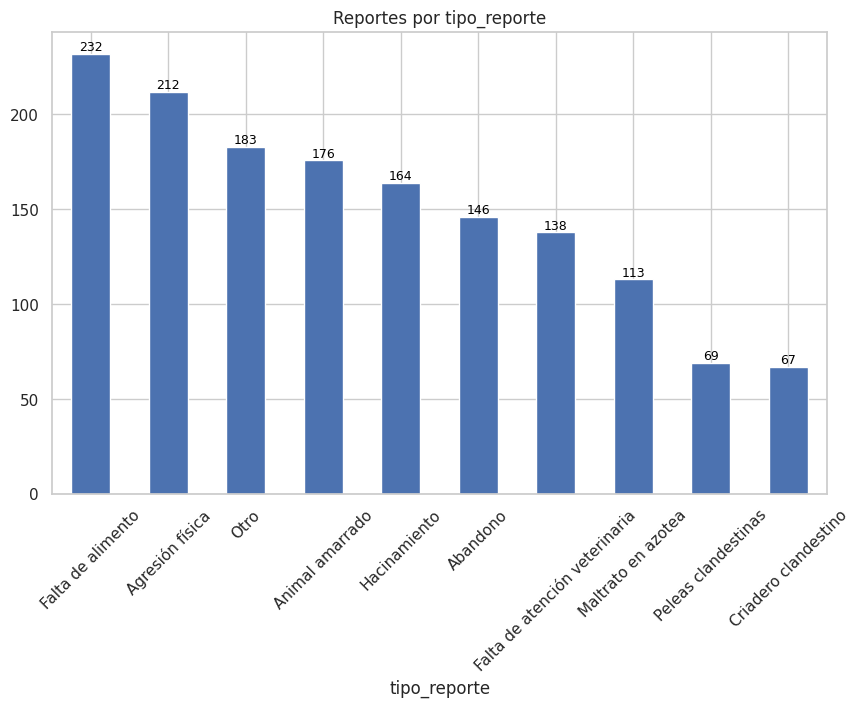

----------------------------------------------------------------------------------------------------
tipo_reporte con más reportes:
Falta de alimento con 232 reportes
----------------------------------------------------------------------------------------------------



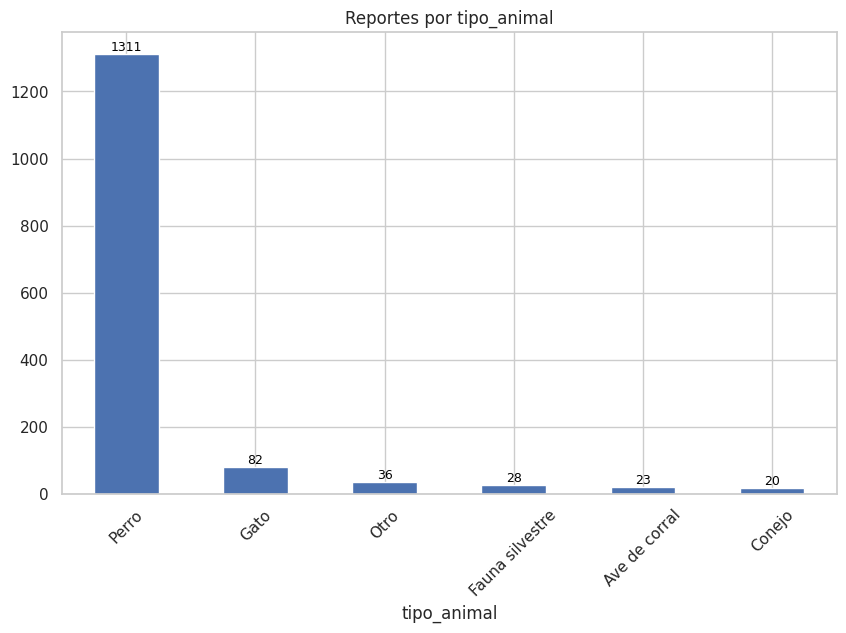

----------------------------------------------------------------------------------------------------
tipo_animal con más reportes:
Perro con 1311 reportes
----------------------------------------------------------------------------------------------------



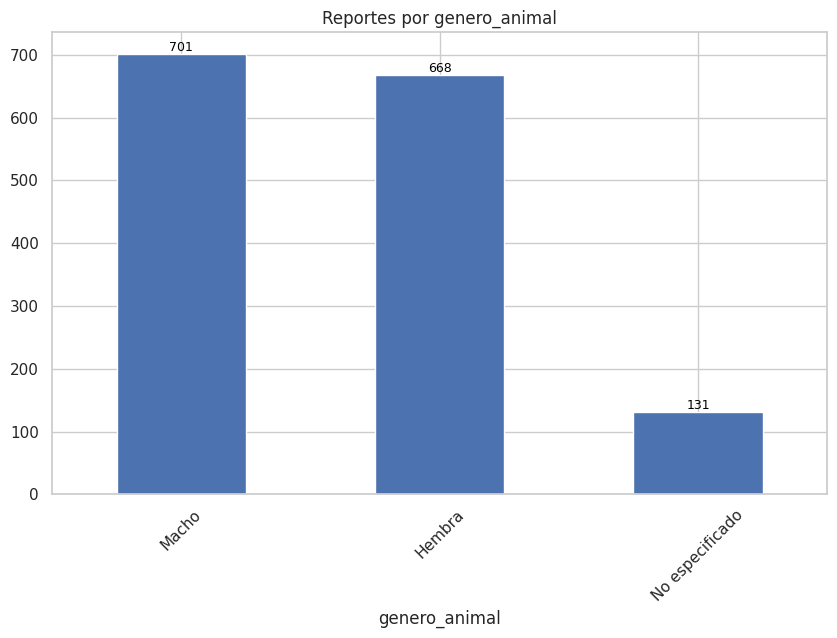

----------------------------------------------------------------------------------------------------
genero_animal con más reportes:
Macho con 701 reportes
----------------------------------------------------------------------------------------------------



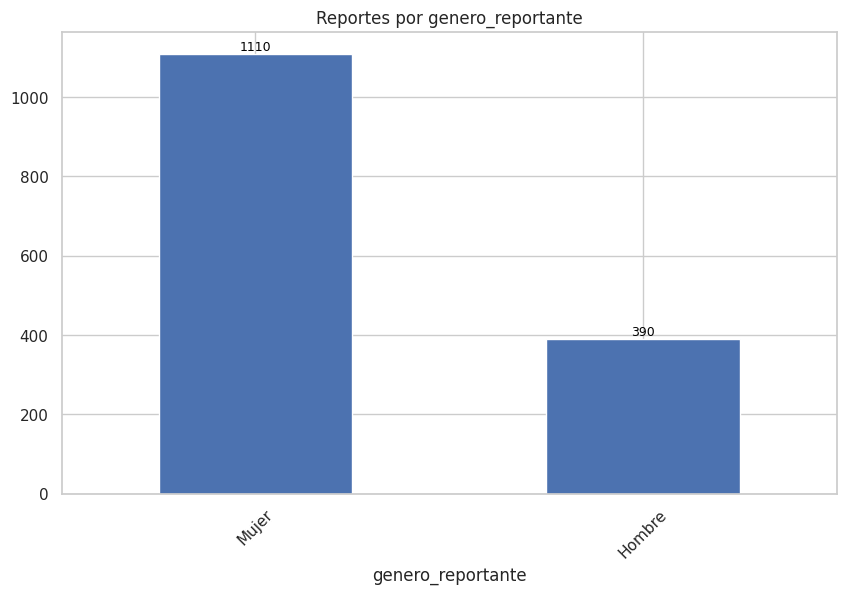

----------------------------------------------------------------------------------------------------
genero_reportante con más reportes:
Mujer con 1110 reportes
----------------------------------------------------------------------------------------------------



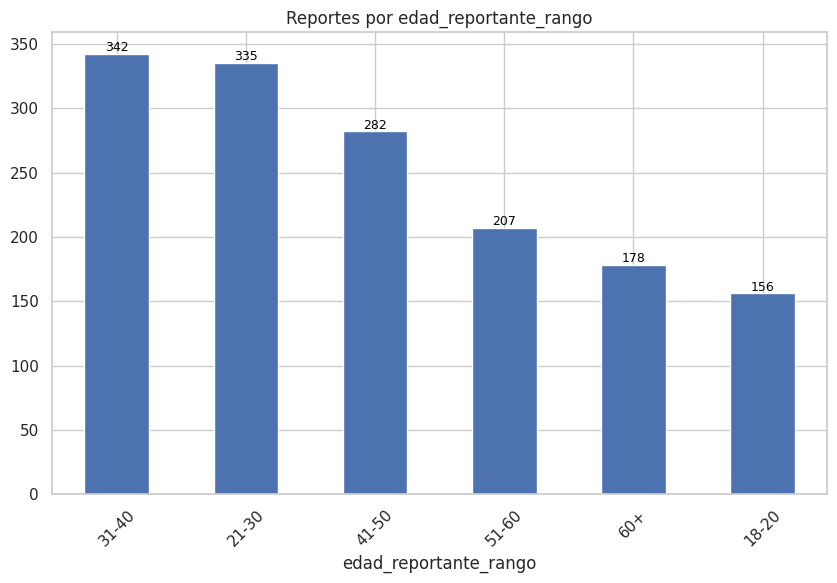

----------------------------------------------------------------------------------------------------
edad_reportante_rango con más reportes:
31-40 con 342 reportes
----------------------------------------------------------------------------------------------------



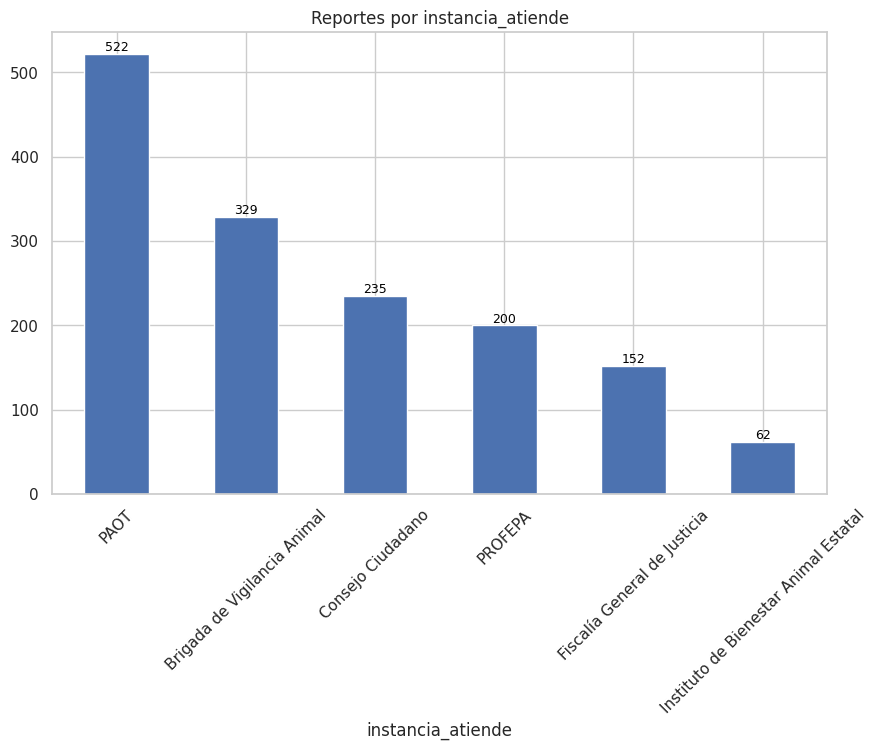

----------------------------------------------------------------------------------------------------
instancia_atiende con más reportes:
PAOT con 522 reportes
----------------------------------------------------------------------------------------------------



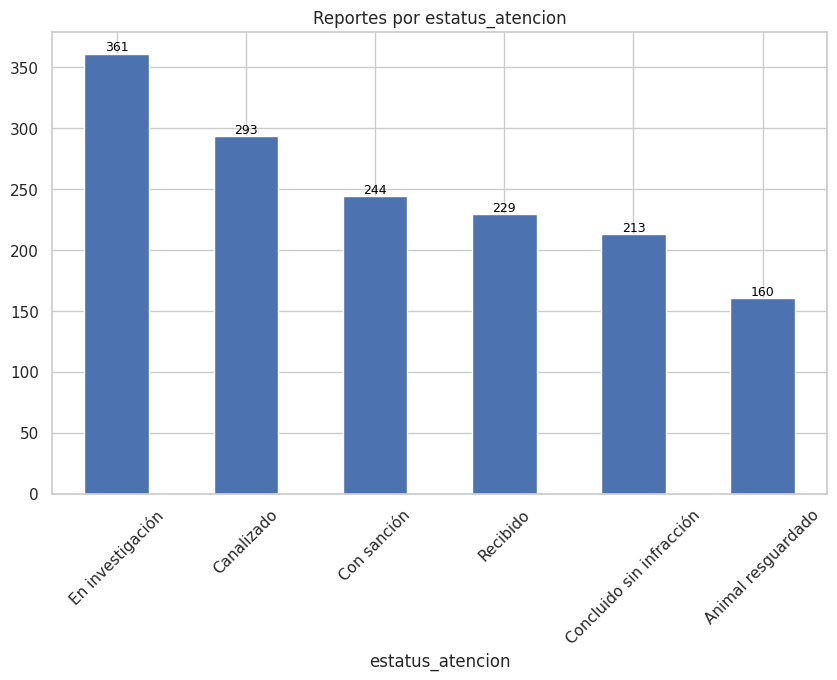

----------------------------------------------------------------------------------------------------
estatus_atencion con más reportes:
En investigación con 361 reportes
----------------------------------------------------------------------------------------------------



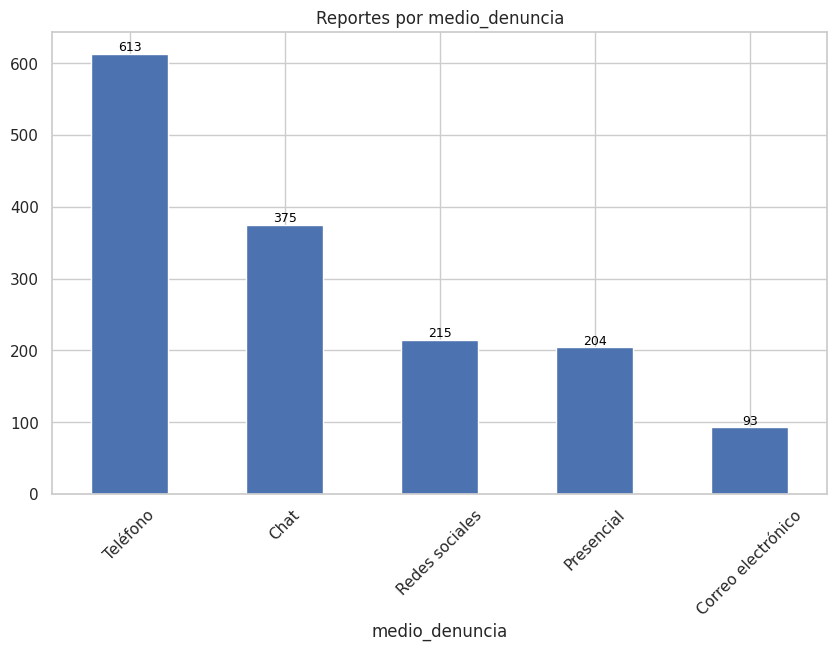

----------------------------------------------------------------------------------------------------
medio_denuncia con más reportes:
Teléfono con 613 reportes
----------------------------------------------------------------------------------------------------



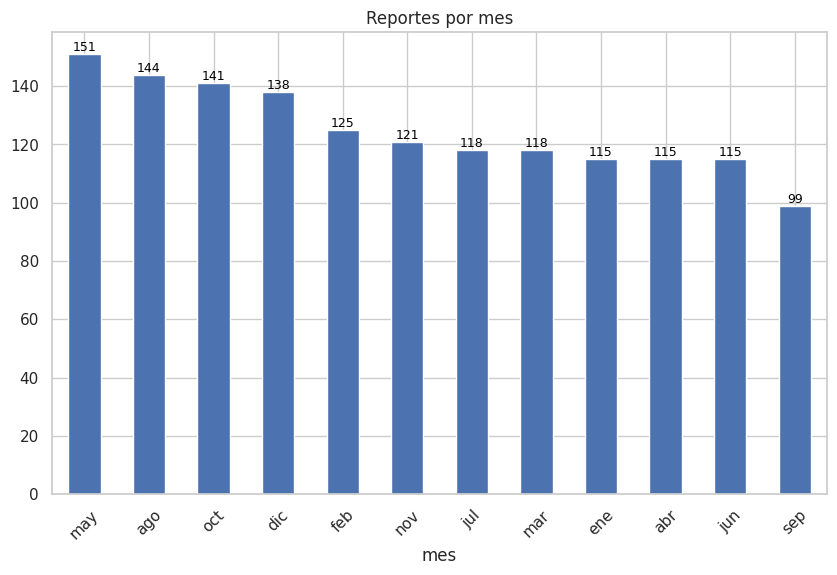

----------------------------------------------------------------------------------------------------
mes con más reportes:
may con 151 reportes
----------------------------------------------------------------------------------------------------



In [178]:
# 3. Categóricas

# graficas por columna
cat_cols = df_clean.select_dtypes(include='category').columns
for col in cat_cols:
    plt.figure()
    ax = df_clean[col].value_counts().plot(kind='bar')
    plt.title(f'Reportes por {col}')
    plt.xticks(rotation=45)

    # etiquetas para las barras
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, color='black')

    plt.show()

    # resumen estadístico
    print("-"*100)
    print(f'{col} con más reportes:')
    print(f"{resumen_estadistico['top'][col]} con {resumen_estadistico['freq'][col]} reportes")
    print("-"*100)
    print()

In [179]:
# Reportes en 2021

reportes_2021 = df_clean[df_clean['año'] == 2021]['tipo_reporte'].value_counts().reset_index()
reportes_2021.columns = ['Tipo de Reporte', 'Número de Reportes']
reportes_2021 = reportes_2021.sort_values(by='Número de Reportes', ascending=False)
reportes_2021

,Tipo de Reporte,Número de Reportes
0,Agresión física,56
1,Hacinamiento,52
2,Otro,45
3,Falta de alimento,44
4,Animal amarrado,41
5,Maltrato en azotea,30
6,Falta de atención veterinaria,24
7,Abandono,23
8,Criadero clandestino,15
9,Peleas clandestinas,14


In [180]:
import matplotlib.animation as animation
from IPython.display import HTML

reportes_2021_anima = reportes_2021.sort_values(by='Número de Reportes', ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(reportes_2021_anima['Tipo de Reporte'], [0]*len(reportes_2021_anima),
               color=sns.color_palette('viridis', len(reportes_2021_anima)))

ax.set_xlabel('Número de Reportes')
ax.set_ylabel('Tipo de Reporte')

max_reports = reportes_2021_anima['Número de Reportes'].max()
ax.set_xlim(0, max_reports * 1.1)

# etiquetas de las barras
text_labels = []
for i, bar in enumerate(bars):
    label = ax.text(0, bar.get_y() + bar.get_height()/2, '0', ha='left', va='center', fontsize=9, color='black')
    text_labels.append(label)

title_obj = ax.set_title('Tipos de Reporte en 2021')

# actualizar frame
def update(frame):
    artists = []

    # actualiza título (progreso)
    title_obj.set_text(f'Tipos de Reporte en 2021 (Progreso: {frame}%)')
    artists.append(title_obj)

    for i, bar in enumerate(bars):
        target_width = reportes_2021_anima['Número de Reportes'].iloc[i]
        current_width = target_width * (frame / 100.0)
        bar.set_width(current_width)
        artists.append(bar)

        text_labels[i].set_text(f'{int(current_width)}')
        text_labels[i].set_x(current_width + (max_reports * 0.01))
        artists.append(text_labels[i])

    return artists

# animacion
anim = animation.FuncAnimation(fig, update, frames=range(0, 101, 2), interval=50, blit=True)

plt.close(fig)

display(HTML(anim.to_jshtml()))

# --------------------------------------------

# guardar animación en html
with open('Reportes_2021.html', 'w') as f:
    f.write(anim.to_jshtml())

# --------------------------------------------

Output hidden; open in https://colab.research.google.com to view.

Podemos notar que la falta cívica con más reprotes en general no es la misma para el año 2021, que es el año que presenta más reportes.
En resumen, la "Falta de alimento" es el reporte más denucnaiado, seguido de "Agresión física" que es también el reporte más común de 2021.
"Hacinamiento" y "Animal amarrado" son las siguientes faltas más reportadas.

Todas estas faltas corrresponden a situaciones presentes en hogares de México, la convivencia diaria y la falta de educación y empatía a los animales que caracteriza a México coinciden con los patrones que observamos.

Incluso el año 2021 podría ser consecuencia del confinamiento por la pandemia de 2020, que quizás convergió en esta ola de denucias hasta 2021.

Podremos averiguar si los meses de las denuncias nos ayudan a aclarar más el panorama.

In [181]:
# comparación entre reportes totales y 2021

reportes_count = df_clean['tipo_reporte'].value_counts().reset_index()
reportes_count.columns = ['Tipo de Reporte', 'Número de Reportes (Total)']

comparacion = pd.merge(reportes_count, reportes_2021, on='Tipo de Reporte', how='left')
comparacion.rename(columns={'Número de Reportes': 'Número de Reportes (2021)'}, inplace=True)

tabla = comparacion.sort_values(by='Número de Reportes (Total)', ascending=False)
display(tabla)

,Tipo de Reporte,Número de Reportes (Total),Número de Reportes (2021)
0,Falta de alimento,232,44
1,Agresión física,212,56
2,Otro,183,45
3,Animal amarrado,176,41
4,Hacinamiento,164,52
5,Abandono,146,23
6,Falta de atención veterinaria,138,24
7,Maltrato en azotea,113,30
8,Peleas clandestinas,69,14
9,Criadero clandestino,67,15


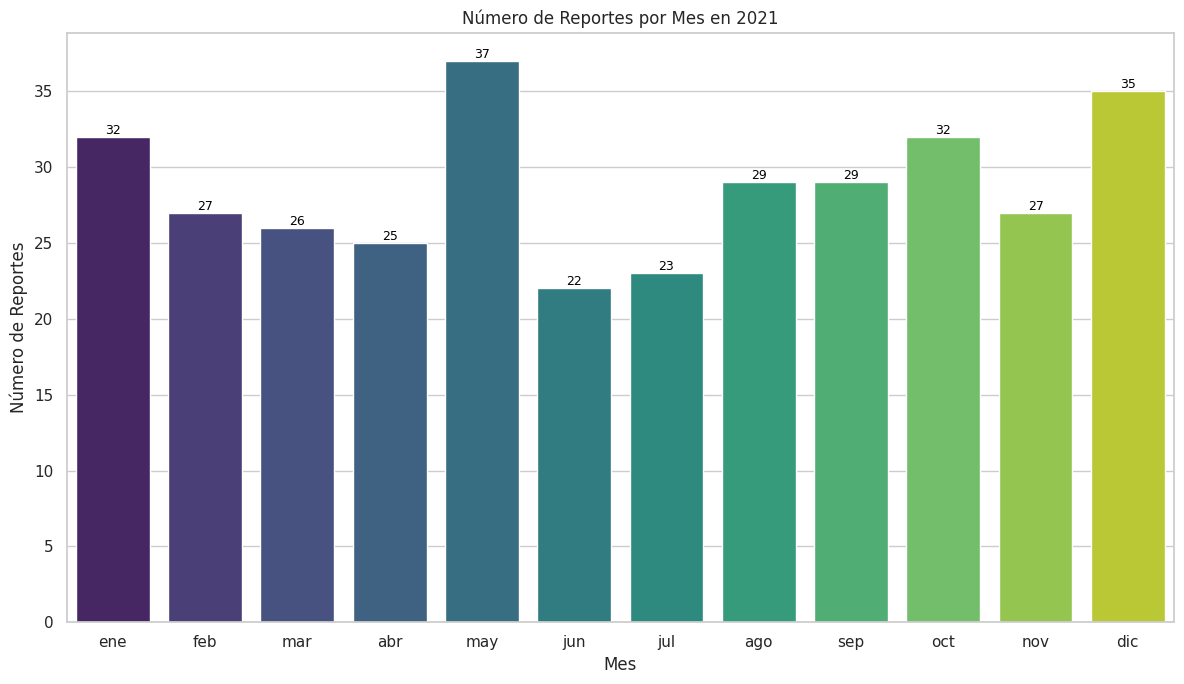

In [182]:
# reportes por mes en 2021

reportes_mes_2021 = df_clean[df_clean['año'] == 2021]['mes'].value_counts().reset_index()
reportes_mes_2021.columns = ['Mes', 'Número de Reportes']

mes_sort = ['ene', 'feb', 'mar', 'abr', 'may', 'jun', 'jul', 'ago', 'sep', 'oct', 'nov', 'dic']
reportes_mes_2021['Mes'] = pd.Categorical(reportes_mes_2021['Mes'], categories=mes_sort, ordered=True)
reportes_mes_2021 = reportes_mes_2021.sort_values('Mes')

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Mes', y='Número de Reportes', data=reportes_mes_2021, palette='viridis', hue='Mes', legend=False)
plt.title('Número de Reportes por Mes en 2021')
plt.xlabel('Mes')
plt.ylabel('Número de Reportes')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()

Notablemente todo el año presentó diversos reportes, si bien el mes de mayo coincide en el análisis general y en 2021, los demás meses presentan igual cantidad de reportes.

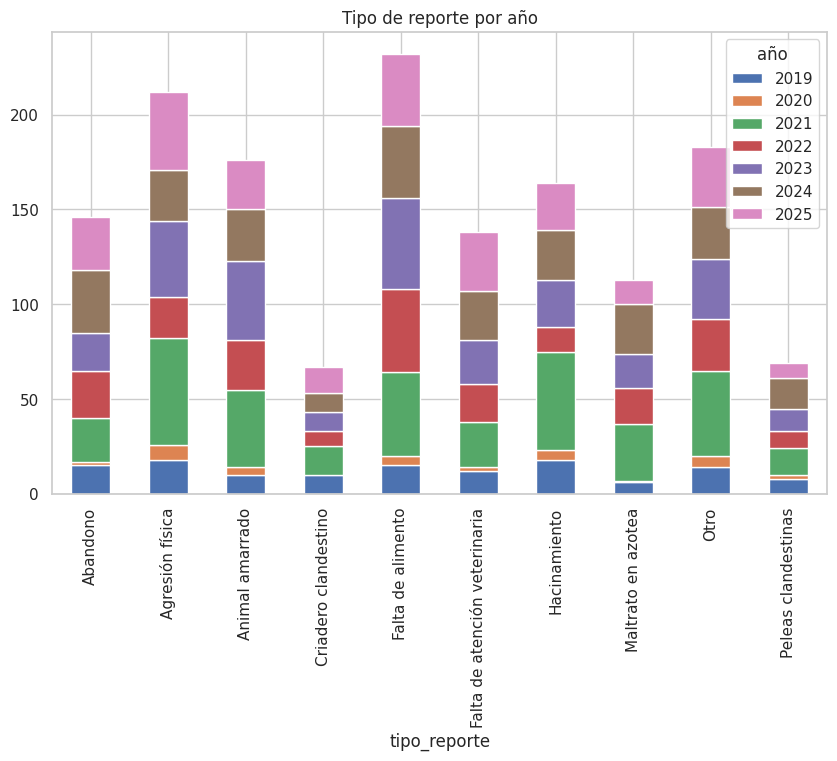

In [183]:
# 4. Numérica vs Categórica - Tipo de reporte por año

pd.crosstab(df_clean['tipo_reporte'], df_clean['año']).plot(kind='bar', stacked=True)
plt.title('Tipo de reporte por año')
plt.show()

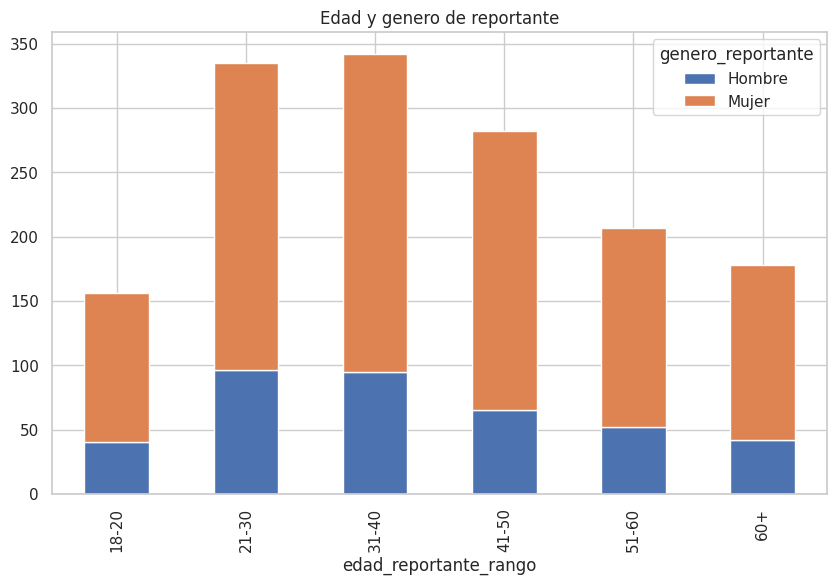

----------------------------------------------------------------------------------------------------
Edad de reportante con más reportes:
31-40 con 342 reportes
----------------------------------------------------------------------------------------------------



In [184]:
# 5. Categórica vs Categórica - edad de reportante y genero de reportante

pd.crosstab(df_clean['edad_reportante_rango'], df_clean['genero_reportante']).plot(kind='bar', stacked=True)
plt.title('Edad y genero de reportante')
plt.show()

print("-"*100)
print(f"Edad de reportante con más reportes:")
print(f"{resumen_estadistico['top']['edad_reportante_rango']} con {resumen_estadistico['freq']['edad_reportante_rango']} reportes")
print("-"*100)
print()

In [185]:
# comparación de edad y género

comparacion_edad_genero = pd.crosstab(df_clean['edad_reportante_rango'], df_clean['genero_reportante']).sort_values(by='edad_reportante_rango', ascending=True)
comparacion_edad_genero.rename(columns={'Mujer': 'Mujeres', 'Hombre': 'Hombres'}, inplace=True)
comparacion_edad_genero['Total'] = comparacion_edad_genero['Mujeres'] + comparacion_edad_genero['Hombres']
display(comparacion_edad_genero)

genero_reportante,Hombres,Mujeres,Total
edad_reportante_rango,,,
18-20,40,116,156
21-30,96,239,335
31-40,95,247,342
41-50,65,217,282
51-60,52,155,207
60+,42,136,178


Evidentemente hay un patron entre reportantes mujeres y reportantes hombres, así mismo en los rangos de 31 a 40 y posteriormente de 21 a 30.  
La causa puede ser que la empatía y las emociones son más predominantes entre las mujeres. Los rangos de edad pueden responder a:

* 31-40, un grupo de mujeres adultas con conciencia y responsabilidad social y los medios necesarios para generar las denuncias.

* 21-30, un grupo de mujeres, sí adultas, jóvenes con tendencia a redes sociales y a la facilidad de las nuevas tecnologías para tener acercamientos a estos reportes.

Comprobemos si los datos nos dan la razón.

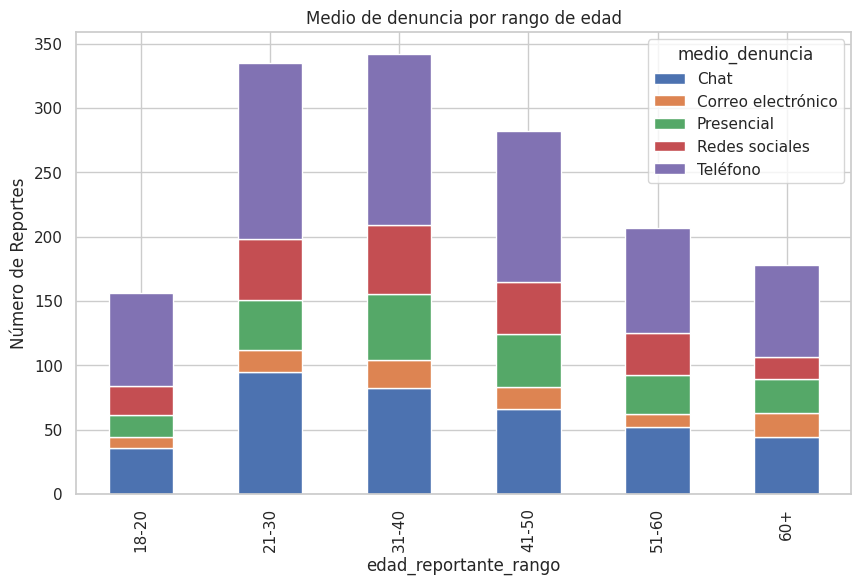

----------------------------------------------------------------------------------------------------
Medio de denuncua con más reportes:
Teléfono con 613 reportes
----------------------------------------------------------------------------------------------------



In [186]:
# edad de reportante y medio de denuncia

pd.crosstab(df_clean['edad_reportante_rango'], df_clean['medio_denuncia']).plot(kind='bar', stacked=True)
plt.title('Medio de denuncia por rango de edad')
plt.ylabel('Número de Reportes')
plt.show()

print("-"*100)
print(f"Medio de denuncua con más reportes:")
print(f"{resumen_estadistico['top']['medio_denuncia']} con {resumen_estadistico['freq']['medio_denuncia']} reportes")
print("-"*100)
print()

In [187]:
# medio de atención por rango de edad, sólo mujeres

mujeres = df_clean[df_clean['genero_reportante'] == 'Mujer']
comparacion_edad_medio = pd.crosstab(mujeres['edad_reportante_rango'], mujeres['medio_denuncia']).sort_values(by='edad_reportante_rango', ascending=True)

cols = ['Chat', 'Correo electrónico', 'Presencial', 'Redes sociales', 'Teléfono']
comparacion_edad_medio['Total'] = comparacion_edad_medio[cols].sum(axis=1)

display(comparacion_edad_medio)

medio_denuncia,Chat,Correo electrónico,Presencial,Redes sociales,Teléfono,Total
edad_reportante_rango,,,,,,
18-20,27,5,13,17,54,116
21-30,70,12,29,27,101,239
31-40,59,15,43,41,89,247
41-50,49,15,35,33,85,217
51-60,37,10,24,23,61,155
60+,37,12,17,13,57,136


El medio de denuncia más usado es el teléfono, y contrario a lo que pensábamos, el grupo predominante en denucnaias, ya sea por teléfono o chat es el de 21-30. De hecho, el grupo de 31-40 tiene un total mayor de denuncias ya que usa todos los medios de denuncias de manera activa. A diferencia del grupo de 21-30 que concentra la mayoría de sus denuncias vía teléfono y posteriormente chat.

Sin embargo, seguimos firmes en que es un grupo con conciencia y responsabilidad social.

Por último, queremos analizar el estatus de cada caso, sí existe correlación con la dependencia que atiende o con el tipo de reporte registrado.

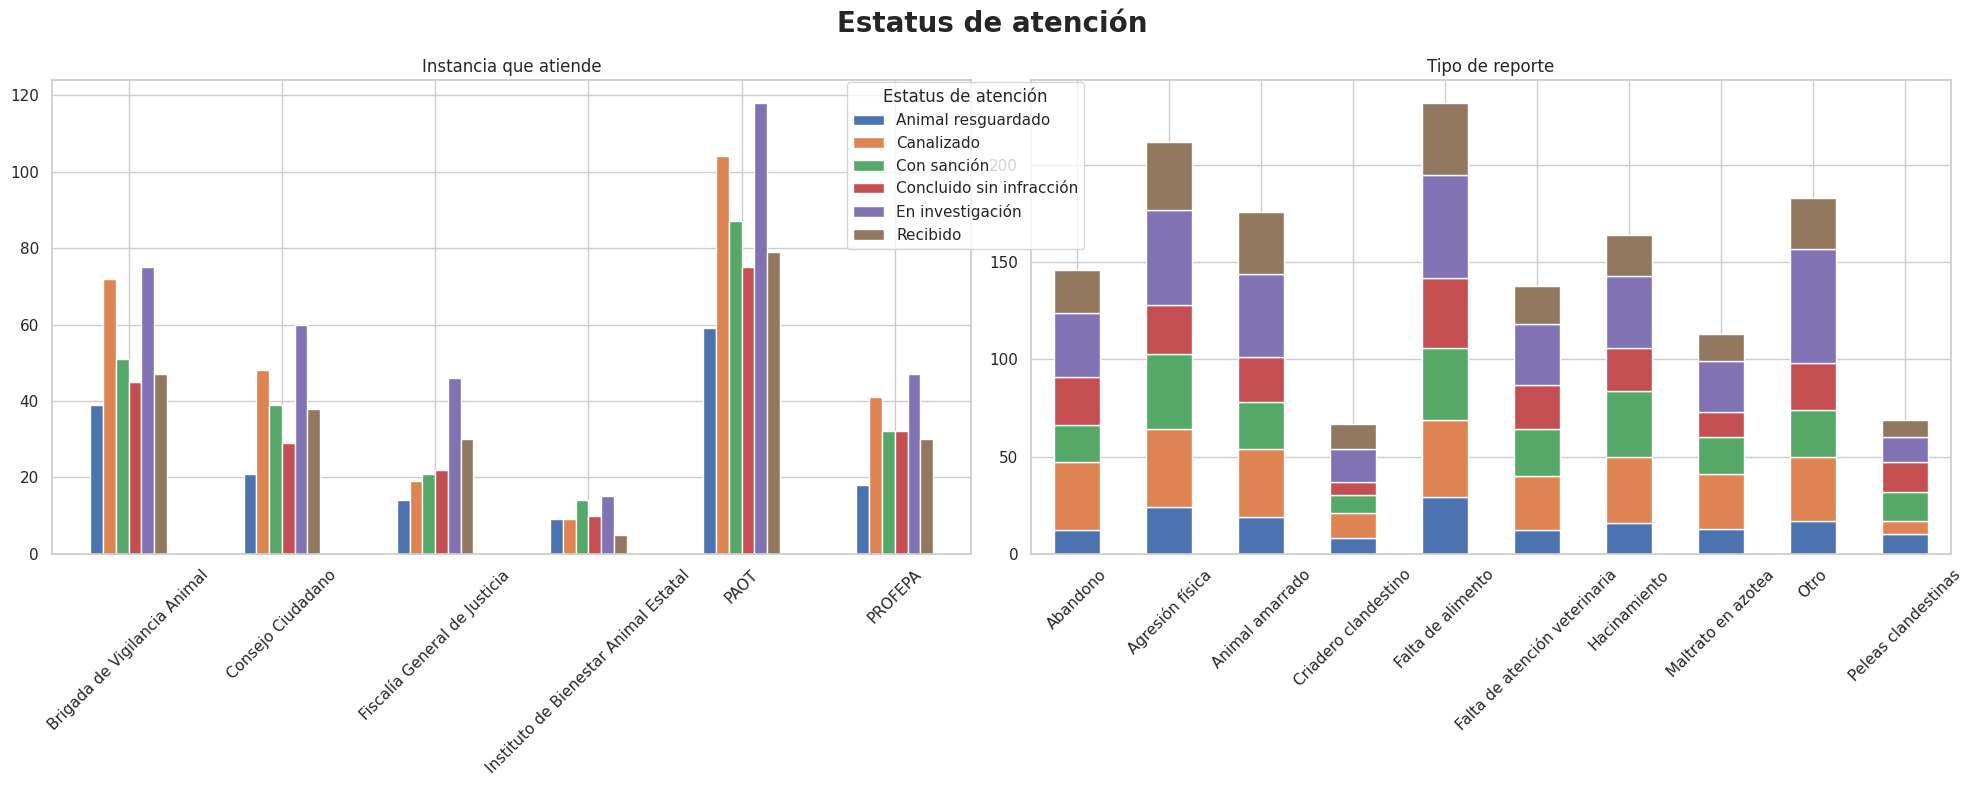

In [188]:
# correlación entre el estatus del reporte, la instancia y el tipo de reporte

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
set_title_font_size = 20
set_title_font_weight = 'bold'
set_title = 'Estatus de atención'

# Gráfica 1: Estatus de reporte por instancia que atiende
crosstab_instancia_estatus = pd.crosstab(df_clean['instancia_atiende'], df_clean['estatus_atencion'])
plot0 = crosstab_instancia_estatus.plot(kind='bar', stacked=False, ax=axes[0])
axes[0].set_title('Instancia que atiende')
axes[0].set_xlabel('')
axes[0].get_legend().remove()
axes[0].tick_params(axis='x', rotation=45)

# Gráfica 2: Estatus de reporte por tipo de reporte
crosstab_tipo_estatus = pd.crosstab(df_clean['tipo_reporte'], df_clean['estatus_atencion'])
plot1 = crosstab_tipo_estatus.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Tipo de reporte')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].get_legend().remove()
axes[1].tick_params(axis='x', rotation=45)

handles, labels = plot0.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.55, 0.9), title='Estatus de atención')

plt.suptitle(set_title, fontsize=set_title_font_size, fontweight=set_title_font_weight)
plt.tight_layout()
plt.show()

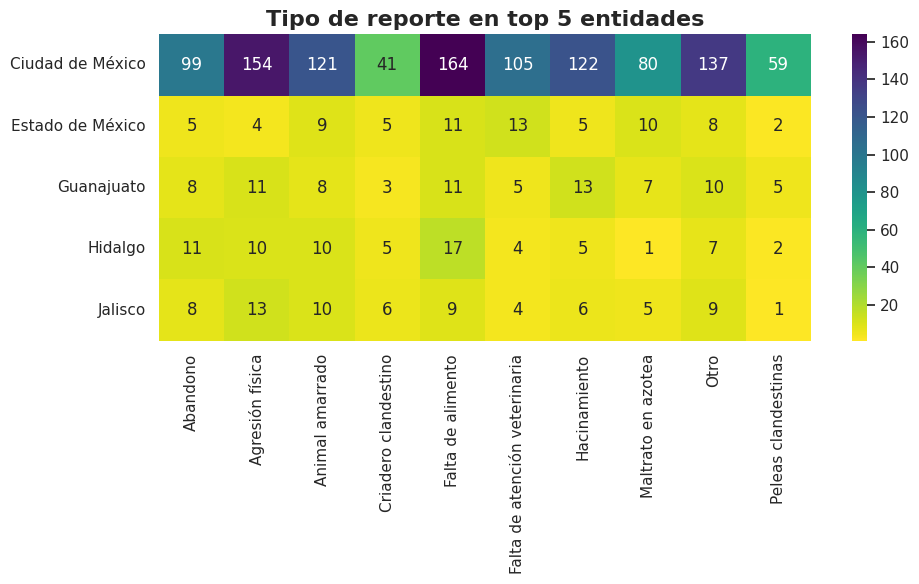

In [189]:
# entidades federativas con mayor cantidad de reportes

top5_ent = df_clean['entidad_federativa'].value_counts().head(5).index
heat = pd.crosstab(df_clean[df_clean['entidad_federativa'].isin(top5_ent)]['entidad_federativa'],
                   df_clean['tipo_reporte'])
sns.heatmap(heat, annot=True, fmt='d', cmap='viridis_r')
plt.title('Tipo de reporte en top 5 entidades', fontsize = 16, fontweight = 'bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [190]:
# Reportes por alcaldía

reportes_por_alcaldia = df_clean['alcaldia_municipio'].value_counts().reset_index()
reportes_por_alcaldia.columns = ['alcaldia', '#_reportes']
# Excluir 'Municipio' de los reportes por alcaldía
reportes_por_alcaldia = reportes_por_alcaldia[reportes_por_alcaldia['alcaldia'] != 'Municipio']
display(reportes_por_alcaldia.head())

,alcaldia,#_reportes
1,Cuauhtémoc,118
2,Álvaro Obregón,115
3,Gustavo A. Madero,111
4,Iztacalco,109
5,Azcapotzalco,108


In [191]:
import json
import plotly.express as px

# Leemos GeoJSON
try:
    with open('/content/maltrato.geojson', 'r') as f:
        cdmx_geojson = json.load(f)
except FileNotFoundError:
    print("Error: maltrato.geojson not found. Please ensure the file is in '/content/'.")
    cdmx_geojson = None

if cdmx_geojson and 'reportes_por_alcaldia' in locals():
    fig = px.choropleth_mapbox(
        reportes_por_alcaldia,
        geojson=cdmx_geojson,
        locations="alcaldia",
        featureidkey="properties.neighbourhood",
        color="#_reportes",
        color_continuous_scale="GnBu",
        mapbox_style="carto-darkmatter",
        zoom=9,
        center={"lat": 19.4326, "lon": -99.1332}, # Coordenadas para CDMX
        opacity=0.7,
        hover_name="alcaldia",
        hover_data={"#_reportes": True},
        title="📍 Número de reportes de Maltrato Animal por Alcaldía en CDMX"
    )
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
    fig.show()
else:
    print("Mapa no leído, revisa el GeoJSON o los datos.")

# --------------------------------------------

# guardar mapa

fig.write_html('Mapa_Reportes_Maltrato_CDMX.html')

# --------------------------------------------

Cómo resumen final y corroborando la información obtenida desde el inicio del análisis, queda la tabla con el top de cada columna de nuestro análisis. Así mismo, complementamos con el año que más reportes tuvo, el 2021.


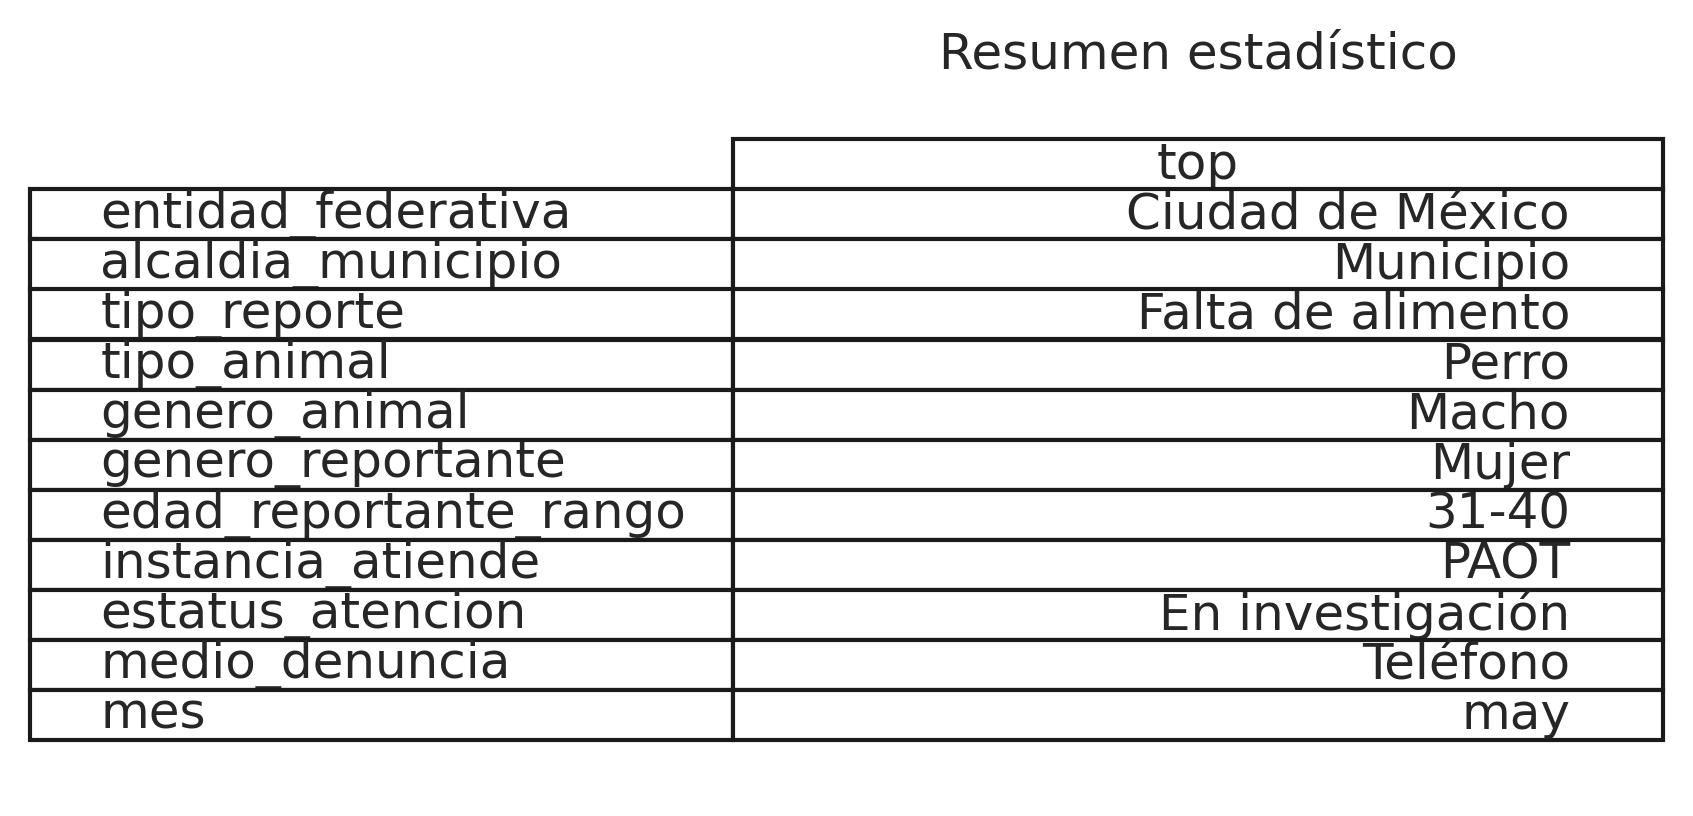


## **Conclusiones**


Podríamos/deberíamos añadir más constantes al ejercicio, como religión, educación, economía, entre otras para obtener mayor claridad en la problemática y cultura de denunciar el maltrato animal.

Sin embargo, y dada la dificultad para obtener el dataset, hemos realizado el análisis con lo mínimo, y aunque no basta para dar respuestas contundentes y 100% reales o causales, podemos concluír lo siguiente:

1. **¿Existe el maltrato animal?**

De primera mano sabemos que sí! Y la evidencia nos lo confirma.

El maltrato animal es un problema real y persistente. La cantidad significativa de reportes en nuestro dataset, con un pico notable en 2021, y la diversidad de tipos de maltrato (como 'Falta de alimento', 'Agresión física', 'Hacinamiento', 'Abandono', entre otros) confirman que estas situaciones ocurren de manera constante y en distintas modalidades.

2. **¿Existe la cultura de denunciar el maltrato animal?**

Sabemos que se puede y que sí existe la cultura, sin embargo responde a patrones peculiares.
*  Género: Las mujeres son considerablemente más activas en la denuncia que los hombres, lo que podría indicar una mayor empatía, conciencia, responsabilidad social o disposición para reportar estas situaciones.
*  Rango de Edad: Los rangos de edad de 31-40 años y 21-30 años son los que generan la mayor cantidad de reportes. El grupo de 31-40 utiliza diversos medios de denuncia activamente, mientras que el grupo de 21-30 concentra sus reportes principalmente a través de 'Teléfono' y 'Chat'. Esto soporta la idea de que estos grupos poseen la conciencia, la responsabilidad social y los medios para realizar denuncias.
*  Medios de Denuncia: El Teléfono es el medio más utilizado para las denuncias, seguido por Chat y Redes Sociales, concistente con los hallazgos de rangos de edad.
*  Distribución Geográfica: Alcaldías como Cuauhtémoc, Álvaro Obregón, Gustavo A. Madero, Iztacalco y Azcapotzalco concentran el mayor número de reportes, lo que podría indicar una mayor incidencia o una mayor cultura de denuncia en estas áreas de la CDMX.


3. **¿Las instancias correspondientes de recibir las denunciar registran y dan seguimiento adecuado a los reportes?**

Los datos muestran que las instancias reciben y procesan los reportes, pero el 'estatus de atención' varía:
*  Instancias como PAOT y Fiscalía General de Justicia son las que manejan el mayor volumen de reportes. PAOT tiene una proporción significativa de casos 'En investigación' y 'Concluido sin infracción', mientras que la Fiscalía General de Justicia tiene muchos casos 'Recibido' y 'En investigación'.
*  La Brigada de Vigilancia Animal destaca por tener un buen número de reportes con estatus de 'Animal resguardado', lo que sugiere una intervención directa y efectiva en ciertos casos.
*  En tipos de reporte más severos como 'Peleas clandestinas', se observa una mayor proporción de casos 'Con sanción', indicando que hay resultados concretos en estos incidentes.

Sin embargo, una cantidad considerable de reportes se mantienen en estatus de 'Recibido' o 'En investigación', lo que puede sugerir tiempos de procesamiento prolongados o la complejidad de ciertos casos.
Situación que puede deberse al tipo de instancia que atiende. Las instancias gubernamentales tienen protocolos de atención definidos pero complejos a diferencia de refugios locales o instancias no gubernamentales que actúan sin protocolos y enfocados a resguardar a la ciudadania y al animal en cuestión.


Según la Secretaría de Seguridad Ciudadana, el protocolo ante una denuncia de maltrato es la siguiente.

>Recepción

El reportante genera la denuncia, la inatancia la recibe y solicita evidencia que respalde dicha denuncia (fotos, videos, escritos, otras denuncias, etc).

>Primer acercamiento

Una vez revisado el caso, se realiza una visita de inspección al domicilio denunciado, se valida que la denuncia sea genuína y se le brinda una charla sobre bienestar animal (según el caso del reporte).  
En caso de que no exista falta cívica, se levanta reporte y se da por concluído.  

>Llamado de atención

En caso de que sí exista una falta cívica, se le proporciona al denunciado una prorroga para atender el incidente, se agenda una segunda visita para validación de la situación y en caso de mejorar se mantiene en monitoreo y se cierra el incidente.

>Resguardo del animal

En el supuesto de que el denunciado no cumpla con las recomendaciones realizadas por las autoridades, se retira el animal y se pone en resguardo. Se realiza evaluación del animal para decidir si se duerme, se atiende y pone en adopción o si debe permanecer bajo resguardo de las autoridades para continuar con una investigación ante la FGJ.

>Denuncia formal ante la FGJ

Sí el incidente escala hasta este nivel, es la Fiscalía General quien se encarga del indicente, hasta dictar sentencia al denunciado y liberar al animal para su reincorporación ante la sociedad.

>Cierre del caso.

Como se puede entender, llegar a un caso cerrado es bastante complicado.


4. **¿Por qué se minimiza el maltrato animal y qué podemos aportar como individuos y sociedad para disminuir el mlatrato?**

Como ya se mencionó, podríamos añadir muchas más variables que nos ayuden a entender el por qué del maltrato animal, sin embargo abordaremos algunas constantes que nos pueden guiar en responder el por qué y el qué podemos hacer:

*  Conciencia Social y Educación: La mayor participación de mujeres y ciertos rangos de edad en las denuncias sugiere una creciente conciencia social y quizás una mayor educación sobre los derechos de los animales y la importancia de reportar el maltrato. Así mismo, el rango de edades de reportantes no habla de que son generaciones jóvenes quienes se preocupan por estos temas.

Apostemos a la educación, a la difusión y en algunos años podríamos ver un cambio significativo.

*  Accesibilidad a Medios de Denuncia: La preferencia por el teléfono y el uso de chat/redes sociales por grupos más jóvenes indica que la accesibilidad y facilidad de los canales de comunicación influyen en la voluntad de denunciar.

Nuevamente, con mayor sifusicón y disponibilidad de la información será más fácil fomentar la cultura de denuncia y el no maltrato animal.

*  Factores Socioeconómicos y Urbanos: Las alcaldías con más reportes pueden tener una mayor densidad poblacional, mayor visibilidad de los casos de maltrato, o simplemente una población más consciente y activa en la denuncia.  

Por otro lado, las áreas de oportunidad en otros estados de la república, donde no existen protocolos tan definidos pero sí una falta de empatía y conciencia, no permite a autoridades atender los casos reportados; esto se refleja en la pequeña cantidad de reportes fuera de la CDMX.

Para fomentar la cultura de denuncia y el no maltrato animal, además de lo ya mencionado, podríamos cambiar protocolos, leyes que faciliten no solo la denuncia sino el no maltratar animales ante la amenza de sanciones reales y severas.  
Actualmente, se están reformando las leyes para que los casos de maltrato animal sean llevados de forma más eficiente.

*  Capacidad Institucional: La distribución de los estatus de atención refleja la capacidad y los procesos de cada instancia. La alta proporción de casos 'En investigación' y 'Recibido' podría indicar desafíos en la resolución rápida o una carga de trabajo considerable.  
Nuevamente, nuevos y mejores protocolos son necesarios, mayor capacitación y conciencitazción también al personal gubernamental es fundamental.

*  Contexto Social: El pico de denuncias en 2021 podría estar relacionado con el contexto de la pandemia de 2020, donde un mayor tiempo en casa pudo haber incrementado la observación y denuncia de casos de maltrato animal. Asi mismo, con el confinamiento y una nueva vida digital, la sociedad estába más propensa a la información en redes y a fomentar la acción ante la injusticia.

En resumen, si bien existe un claro problema de maltrato animal y una creciente cultura de denuncia, el seguimiento y la resolución de los casos presentan variaciones que merecen un análisis más profundo para optimizar la respuesta institucional. La incorporación de variables socioeconómicas y culturales adicionales, podría enriquecer aún más estas conclusiones.




### **Denuncia**

Hidalgo está en el top 5 de las entidades federativas con más reportes de maltrato animal.

Denuncia, guíate en el violenciometro y denuncia a la instancia correspondiente. Da voz a los que no la tienen!

> Rescata ⛑️

> Adopta 🐶

> Esteriliza 💉

> Dona 🪙

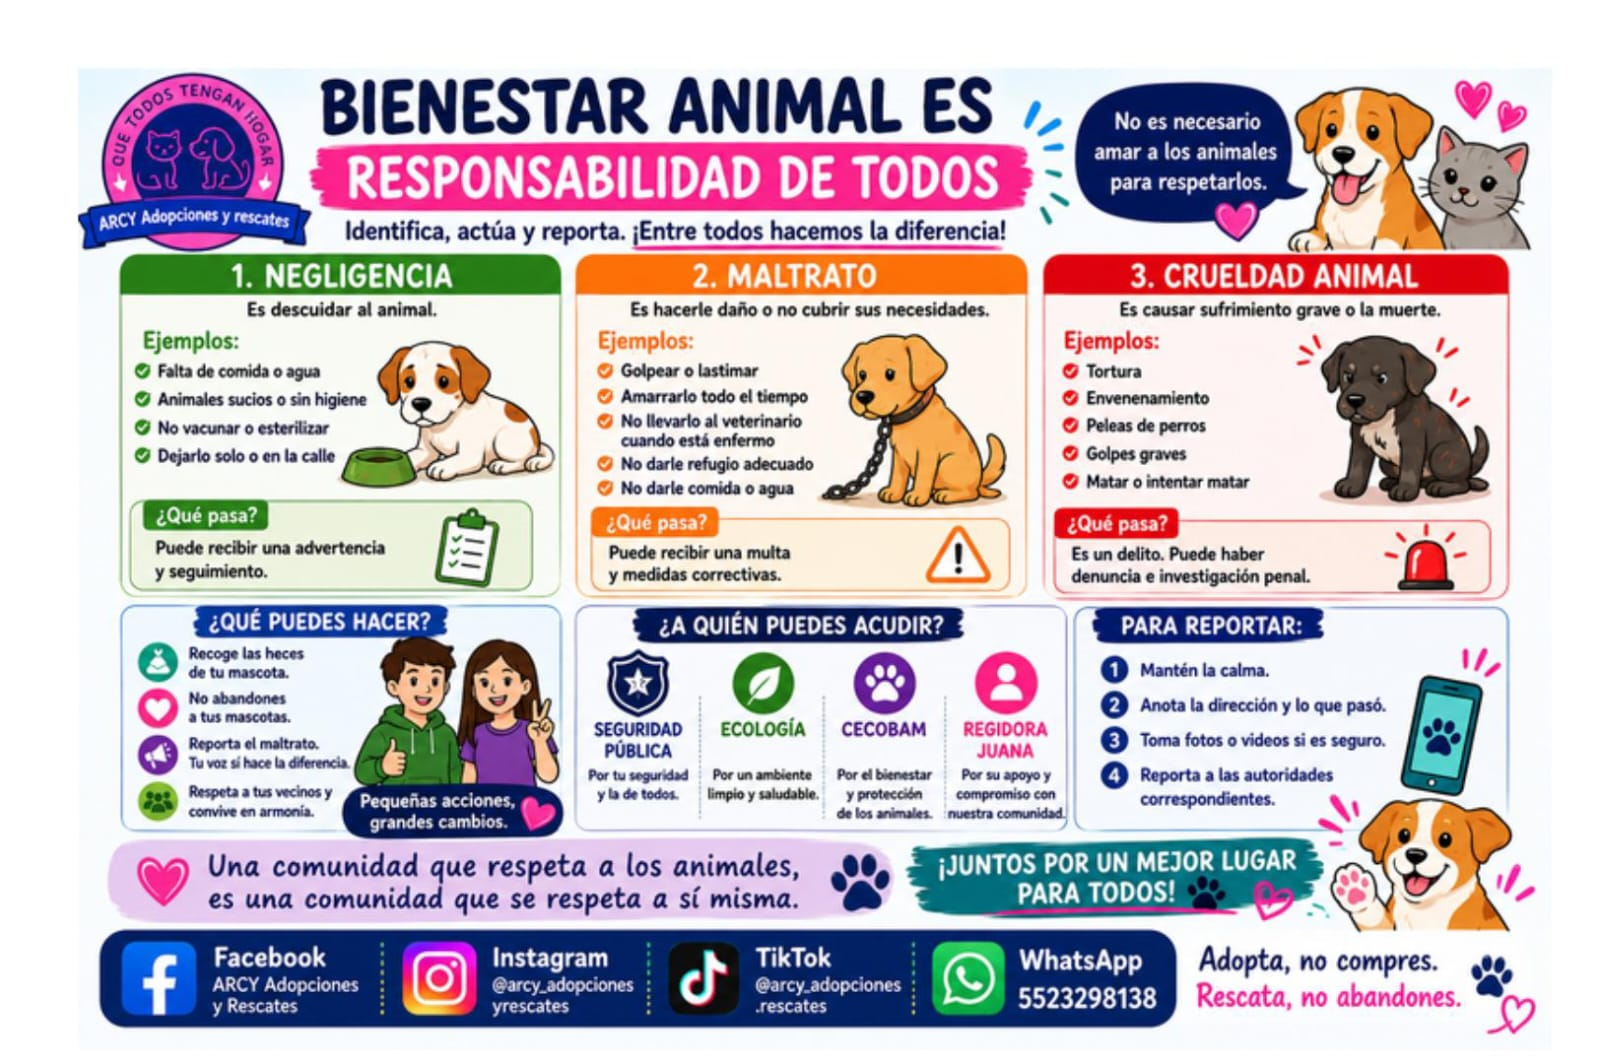